In [37]:
import numpy as np
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/cho-oyu.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/makalu.csv


In [38]:
broadpeek = pd.read_csv('./kaggle/input/broad-peak.csv')
lhotse = pd.read_csv('./kaggle/input/lhotse.csv')
kangchenjunga = pd.read_csv('./kaggle/input/kangchenjunga.csv')
chooyu = pd.read_csv('./kaggle/input/cho-oyu.csv')
manaslu = pd.read_csv('./kaggle/input/manaslu.csv')
dhaulagiri = pd.read_csv('./kaggle/input/dhaulagiri-I.csv')
everest = pd.read_csv('./kaggle/input/everest.csv')
k2 = pd.read_csv('./kaggle/input/k2.csv')
nangaparbat = pd.read_csv('./kaggle/input/nanga-parbat.csv')
gasherbrum2 = pd.read_csv('./kaggle/input/gasherbrum-II.csv')
gasherbrum1 = pd.read_csv('./kaggle/input/gasherbrum-I.csv')
shishapangma = pd.read_csv('./kaggle/input/shishapangma.csv')
annapurna1 = pd.read_csv('./kaggle/input/annapurna-I.csv')
makalu = pd.read_csv('./kaggle/input/makalu.csv')

In [39]:
# Assign mountain in each dataset
broadpeek['mountain'] = 'Broad Peak'
lhotse['mountain'] = 'Lhotse'
kangchenjunga['mountain'] = 'Kangchenjunga'
chooyu['mountain'] = 'Chooyu'
manaslu['mountain'] = 'Manaslu'
dhaulagiri['mountain'] = 'Dhaulagiri I'
everest['mountain'] = 'Everest'
k2['mountain'] = 'K2'
nangaparbat['mountain'] = 'Nanga Parbat'
gasherbrum1['mountain'] = 'Gasherbrum I'
gasherbrum2['mountain'] = 'Gasherbrum II'
makalu['mountain'] = 'Makalu'
annapurna1['mountain'] = 'Annapurna I'
shishapangma['mountain'] = 'Shishapangma'

# Join datasets
allmountains = pd.concat([
    broadpeek, lhotse, kangchenjunga, chooyu, manaslu, dhaulagiri,
    everest, k2, nangaparbat, gasherbrum2, gasherbrum1, 
    shishapangma, annapurna1, makalu
], ignore_index=True)

In [40]:
# Format dates
allmountains['Date'] = pd.to_datetime(allmountains['Date'], format='mixed', errors='coerce')
allmountains['year'] = allmountains['Date'].dt.year
allmountains['month'] = allmountains['Date'].dt.month

# Check if any dates failed to parse
print(f"Missing dates: {allmountains['Date'].isna().sum()}")

# Deaths per year
allmountains['year'].value_counts().sort_index()

Missing dates: 0


year
1895     3
1905     3
1922     7
1924     4
1929     1
        ..
2017     9
2018    16
2019    25
2021    12
2022     4
Name: count, Length: 76, dtype: int64

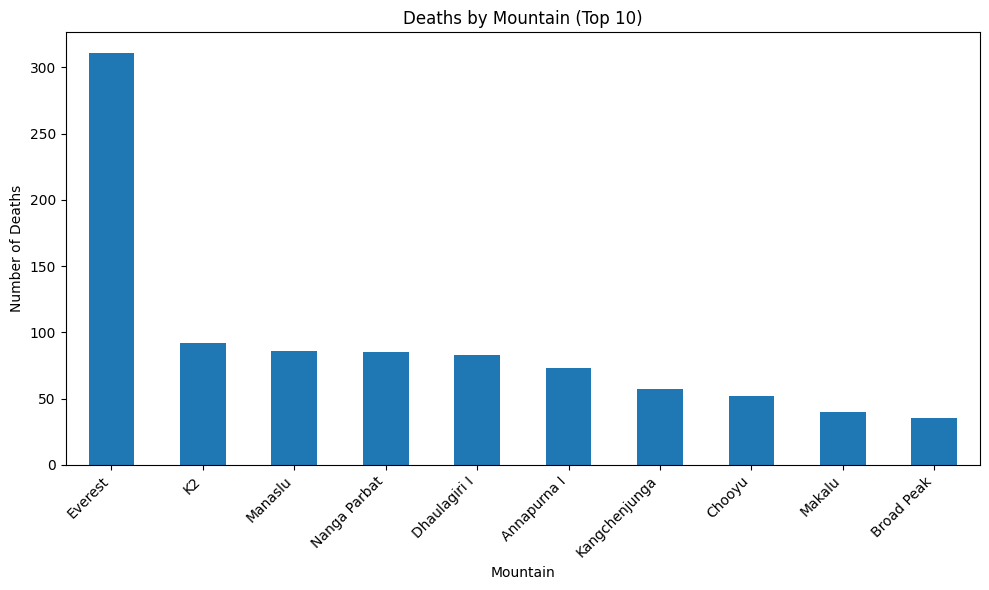

In [74]:
# Top 10 deadliest mountains
allmountains['mountain'].value_counts().head(10).plot(kind='bar', figsize=(10,6))
plt.title('Deaths by Mountain (Top 10)')
plt.xlabel('Mountain')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/deathsbymountain10.png', dpi=300, bbox_inches='tight')
plt.show()

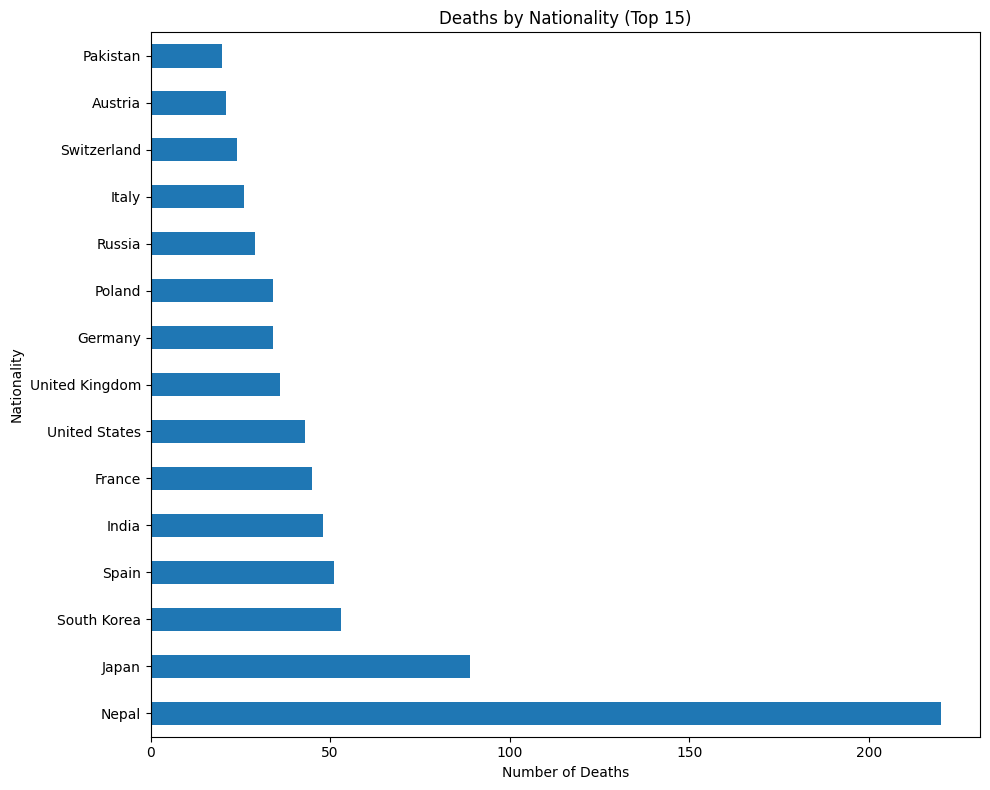

In [76]:
# Top 15 nationalities
allmountains['Nationality'].value_counts().head(15).plot(kind='barh', figsize=(10,8))
plt.title('Deaths by Nationality (Top 15)')
plt.xlabel('Number of Deaths')
plt.ylabel('Nationality')
plt.tight_layout()

# Save plot
plt.savefig('images/bynationality15.png', dpi=300, bbox_inches='tight')
plt.show()

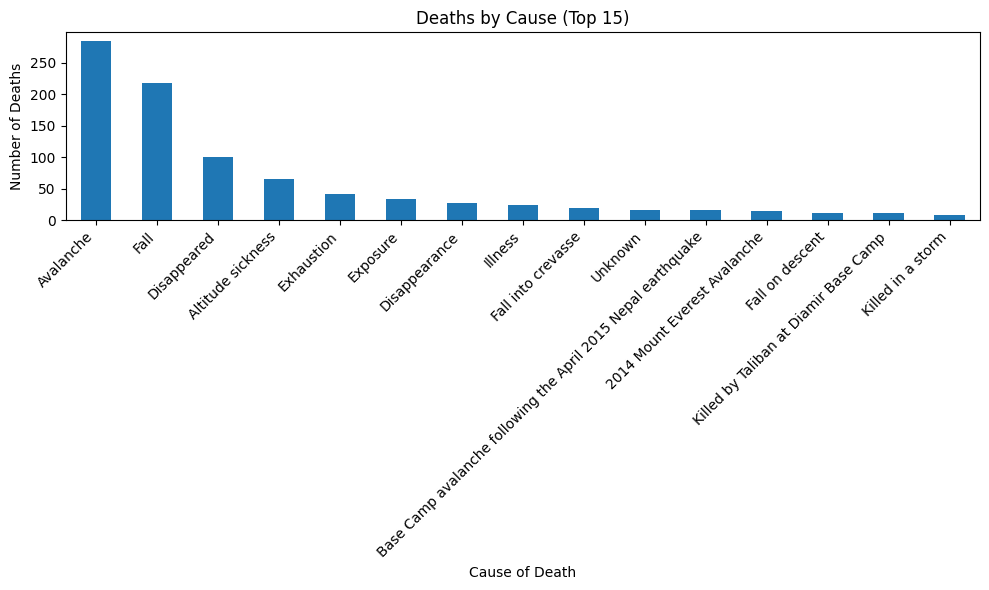

In [77]:
# Causes of death
allmountains['Cause of death'].value_counts().head(15).plot(kind='bar', figsize=(10,6))
plt.title('Deaths by Cause (Top 15)')
plt.xlabel('Cause of Death')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/causes15.png', dpi=300, bbox_inches='tight')
plt.show()

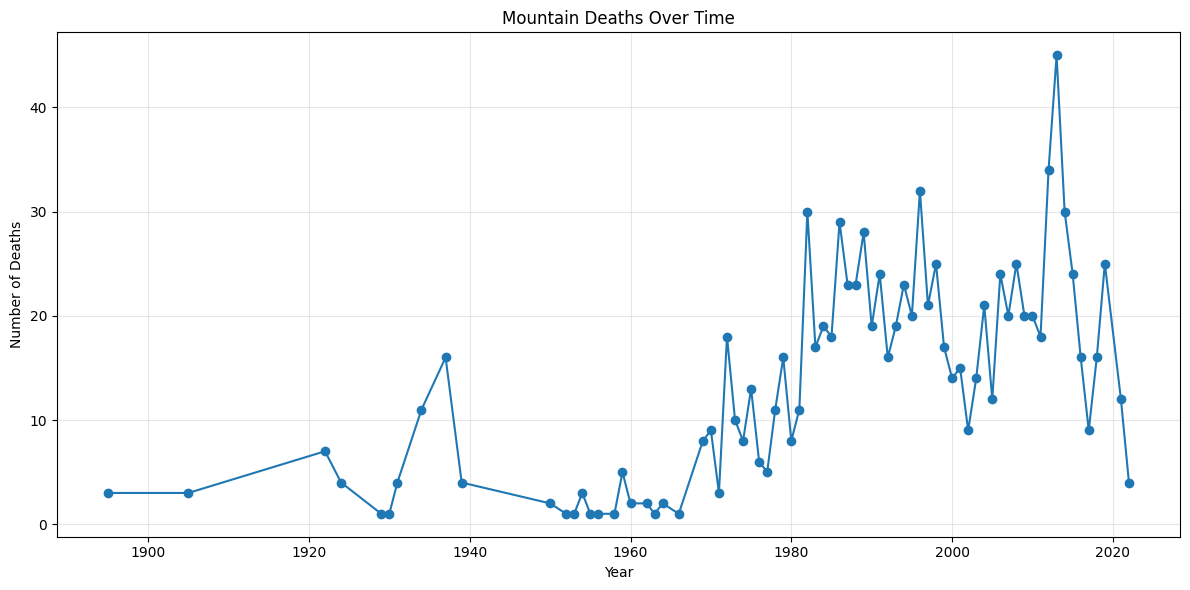

In [78]:
# Deaths over time (by year)
deaths_by_year = allmountains['year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(deaths_by_year.index, deaths_by_year.values, marker='o')
plt.title('Mountain Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/overtime.png', dpi=300, bbox_inches='tight')
plt.show()

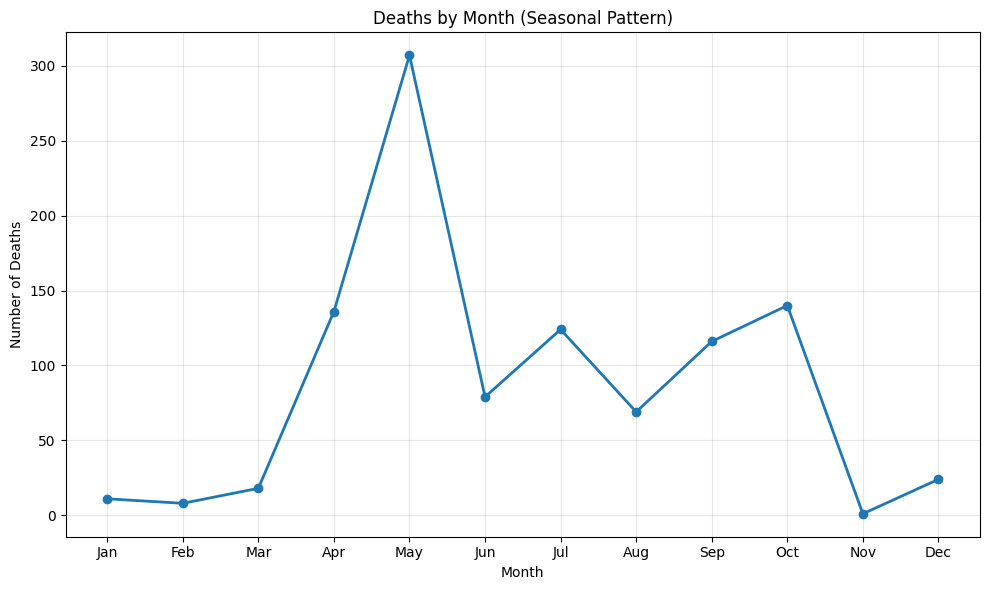

In [79]:
# Deaths by month (seasonal pattern)
deaths_by_month = allmountains['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10,6))
plt.plot(deaths_by_month.index, deaths_by_month.values, marker='o', linewidth=2)
plt.xticks(range(1, 13), month_names)
plt.title('Deaths by Month (Seasonal Pattern)')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/seasonalpattern.png', dpi=300, bbox_inches='tight')
plt.show()

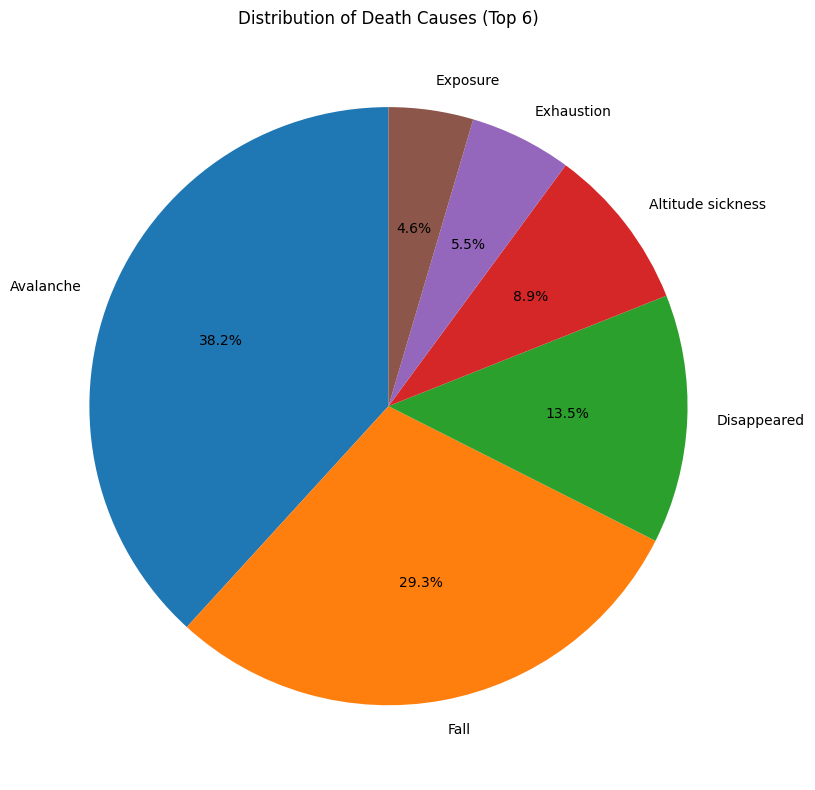

In [80]:
# Top causes of death
top_causes = allmountains['Cause of death'].value_counts().head(6)
plt.figure(figsize=(10,8))
plt.pie(top_causes.values, labels=top_causes.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Death Causes (Top 6)')
plt.tight_layout()

# Save plot
plt.savefig('images/deathcausespie.png', dpi=300, bbox_inches='tight')
plt.show()

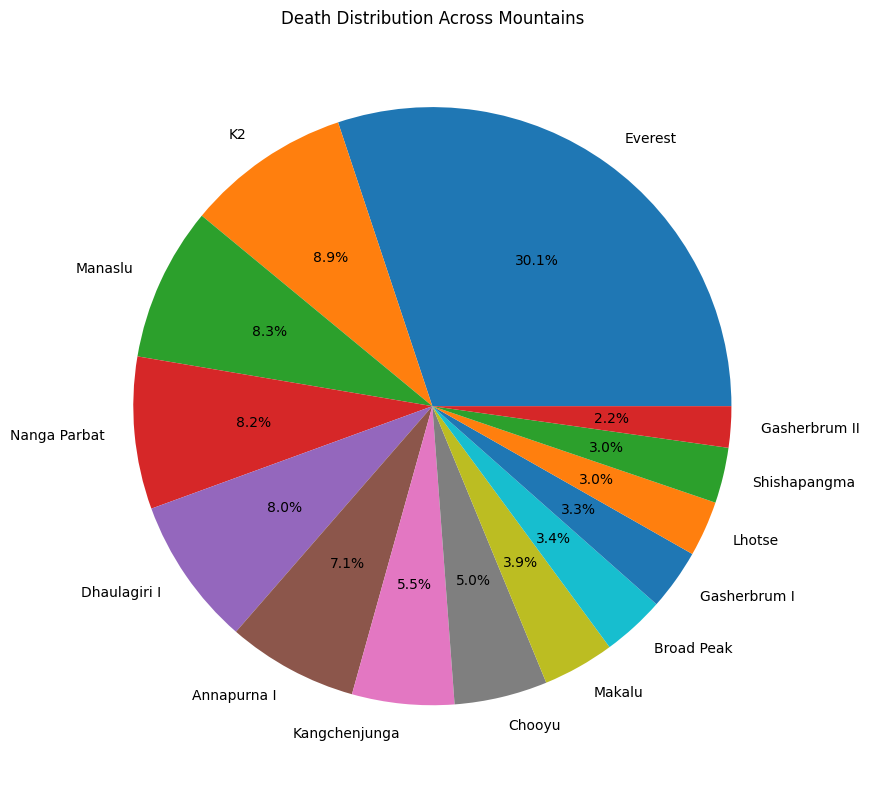

In [81]:
# Deaths by mountain
mountain_deaths = allmountains['mountain'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(mountain_deaths.values, labels=mountain_deaths.index, autopct='%1.1f%%')
plt.title('Death Distribution Across Mountains')
plt.tight_layout()

# Save plot
plt.savefig('images/mountainpie.png', dpi=300, bbox_inches='tight')
plt.show()

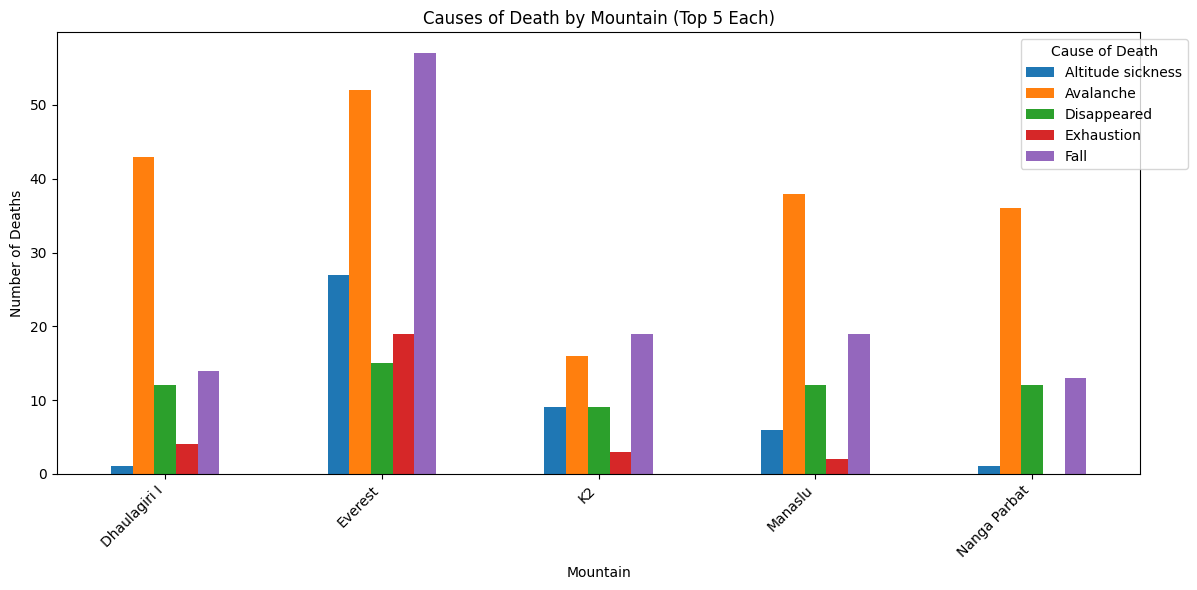

In [82]:
# Top 5 mountains vs top 5 causes of death
top_mountains = allmountains['mountain'].value_counts().head(5).index
top_causes = allmountains['Cause of death'].value_counts().head(5).index

filtered = allmountains[allmountains['mountain'].isin(top_mountains) & 
                        allmountains['Cause of death'].isin(top_causes)]

cause_mountain = pd.crosstab(filtered['mountain'], filtered['Cause of death'])
cause_mountain.plot(kind='bar', figsize=(12,6), stacked=False)
plt.title('Causes of Death by Mountain (Top 5 Each)')
plt.xlabel('Mountain')
plt.ylabel('Number of Deaths')
plt.legend(title='Cause of Death', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/groupeddeathbymountain.png', dpi=300, bbox_inches='tight')
plt.show()

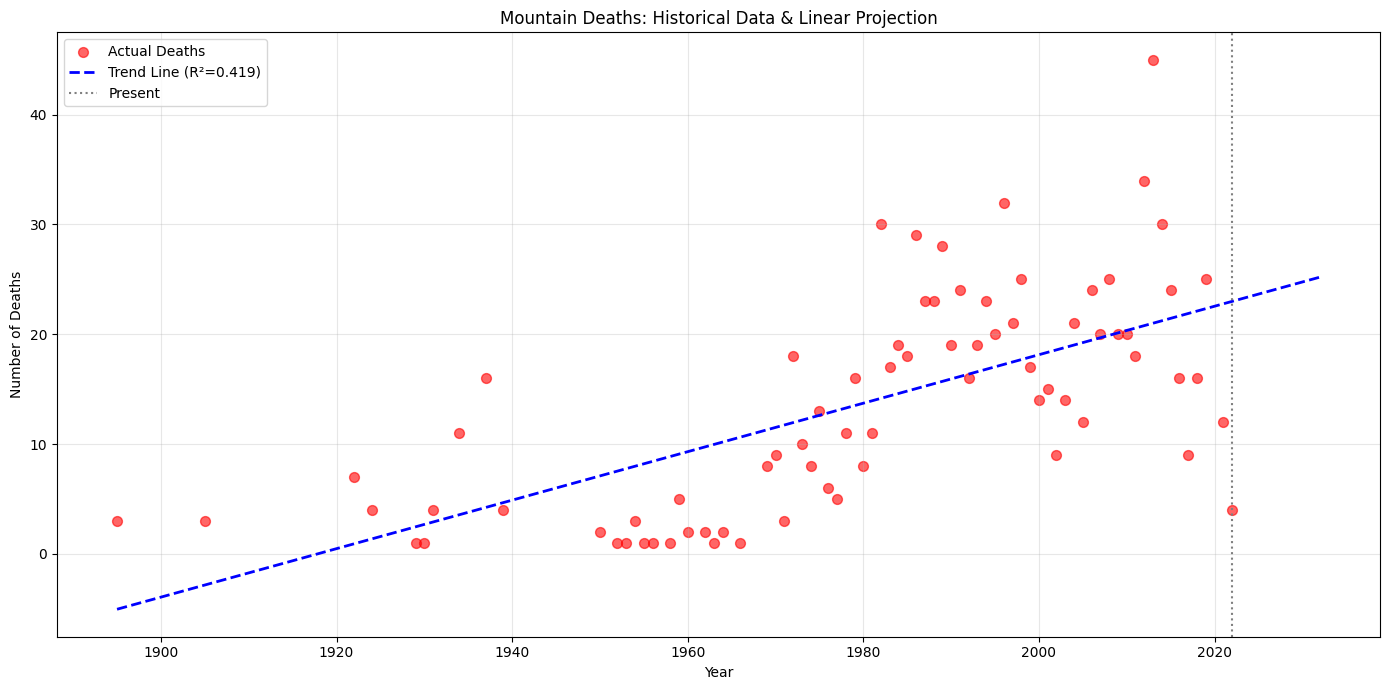

Trend: 0.22 deaths per year
Projected deaths in 2027: 24.1


In [83]:
# Linear regression model on annual deaths
deaths_by_year = allmountains['year'].value_counts().sort_index()
years = deaths_by_year.index.values
deaths = deaths_by_year.values

# Fit linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(years, deaths)

# Project 5-10 years into the future
future_years = np.arange(years.min(), years.max() + 11)
trend_line = slope * future_years + intercept

plt.figure(figsize=(14,7))
plt.scatter(years, deaths, color='red', s=50, alpha=0.6, label='Actual Deaths')
plt.plot(future_years, trend_line, '--', color='blue', linewidth=2, label=f'Trend Line (R²={r_value**2:.3f})')
plt.axvline(x=years.max(), color='gray', linestyle=':', label='Present')
plt.title('Mountain Deaths: Historical Data & Linear Projection')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/linearregression.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Trend: {slope:.2f} deaths per year")
print(f"Projected deaths in {years.max() + 5}: {slope * (years.max() + 5) + intercept:.1f}")

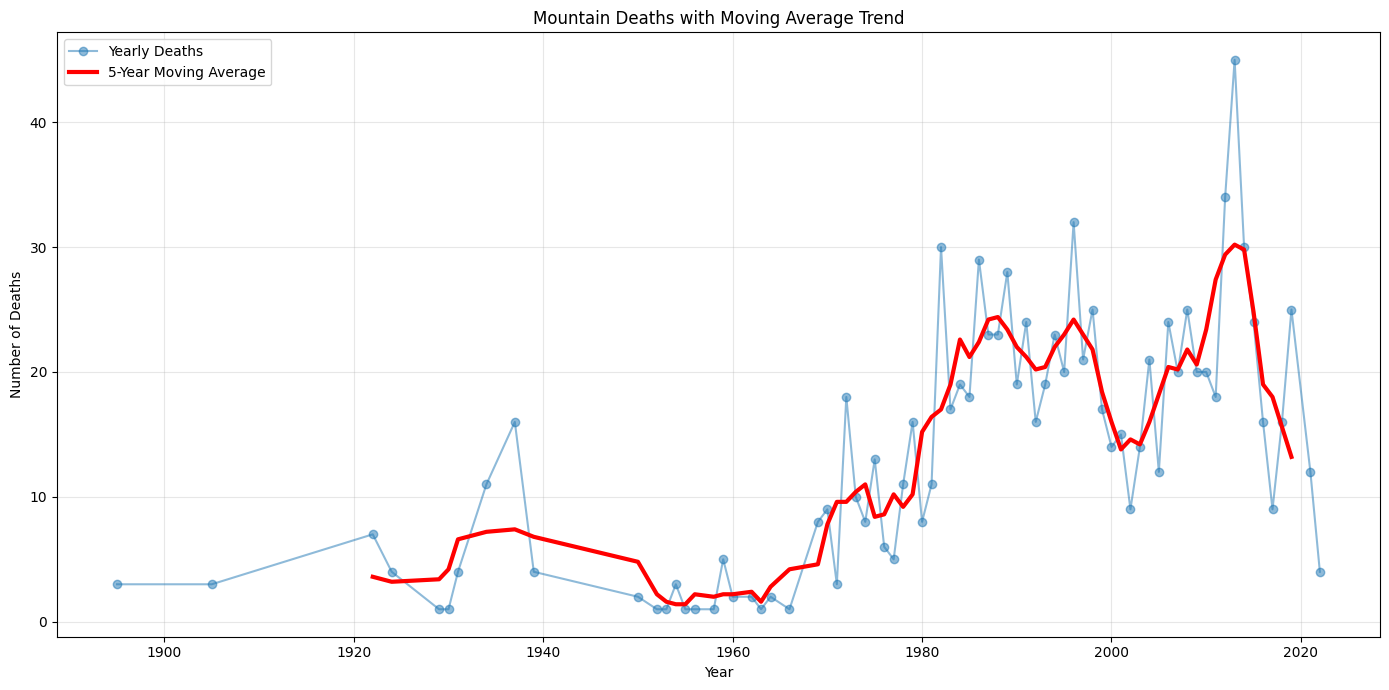

In [84]:
# Trend analysis
# Averaging (not regression model)
# Calculate moving average to smooth out volatility
deaths_by_year_sorted = deaths_by_year.sort_index()
moving_avg = deaths_by_year_sorted.rolling(window=5, center=True).mean()

plt.figure(figsize=(14,7))
plt.plot(deaths_by_year_sorted.index, deaths_by_year_sorted.values, 
         marker='o', alpha=0.5, label='Yearly Deaths')
plt.plot(moving_avg.index, moving_avg.values, 
         linewidth=3, color='red', label='5-Year Moving Average')
plt.title('Mountain Deaths with Moving Average Trend')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/movingaverage.png', dpi=300, bbox_inches='tight')
plt.show()

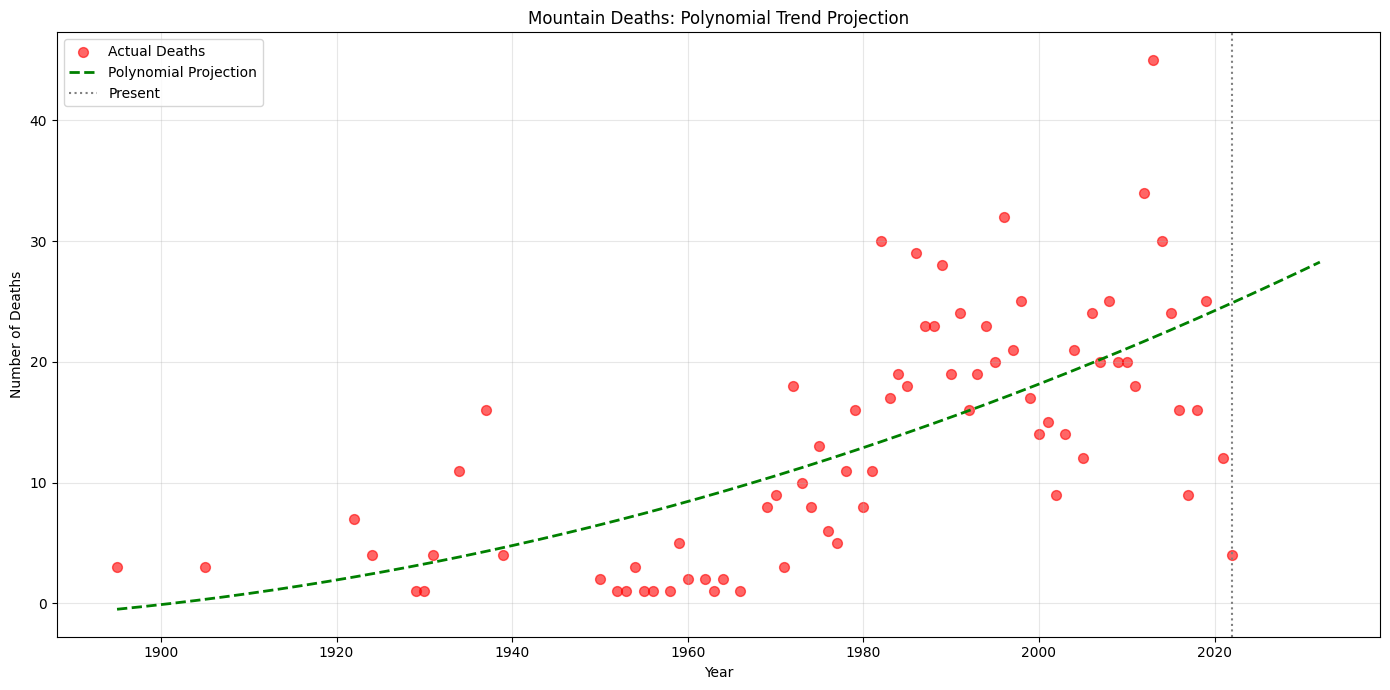

In [86]:
# Polynomial regression model
# Fit polynomial (captures acceleration/deceleration)
coefficients = np.polyfit(years, deaths, deg=2)  # 2nd degree polynomial
poly_trend = np.poly1d(coefficients)

future_years = np.arange(years.min(), years.max() + 11)
projected = poly_trend(future_years)

plt.figure(figsize=(14,7))
plt.scatter(years, deaths, color='red', s=50, alpha=0.6, label='Actual Deaths')
plt.plot(future_years, projected, '--', color='green', linewidth=2, label='Polynomial Projection')
plt.axvline(x=years.max(), color='gray', linestyle=':', label='Present')
plt.title('Mountain Deaths: Polynomial Trend Projection')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/polynomialregressionmodel.png', dpi=300, bbox_inches='tight')
plt.show()

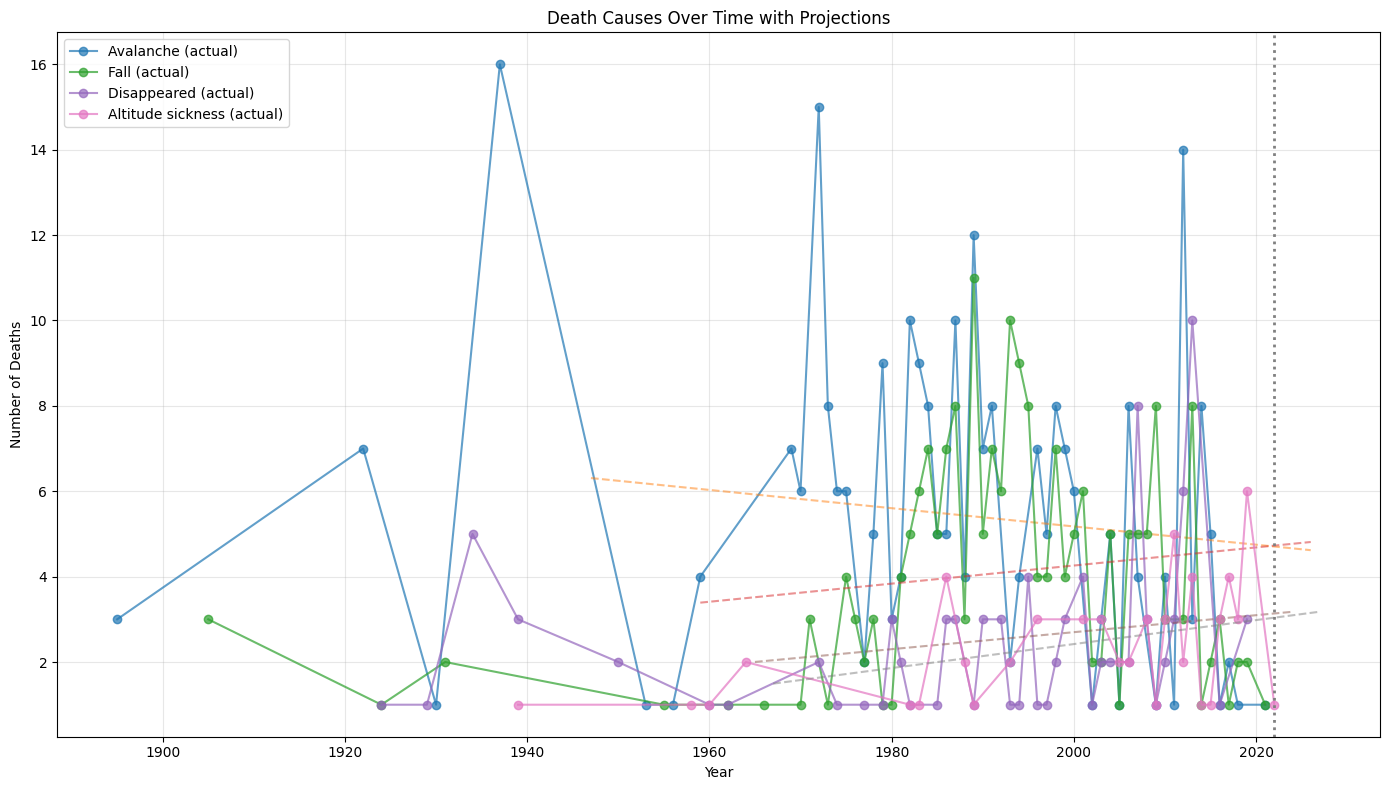

Trend: 0.03 deaths per year
Projected deaths in 2027: 3.2


In [88]:
# Linear regression model
# See which causes are increasing/decreasing
top_causes = allmountains['Cause of death'].value_counts().head(4).index

plt.figure(figsize=(14,8))
for cause in top_causes:
    cause_data = allmountains[allmountains['Cause of death'] == cause]
    yearly = cause_data['year'].value_counts().sort_index()
    
    # Fit trend
    if len(yearly) > 3:  # Need enough data points
        x = yearly.index.values
        y = yearly.values
        slope, intercept = np.polyfit(x, y, 1)
        
        # Project
        future = np.arange(x.min(), x.max() + 6)
        projection = slope * future + intercept
        
        plt.plot(yearly.index, yearly.values, 'o-', alpha=0.7, label=f'{cause} (actual)')
        plt.plot(future[len(x):], projection[len(x):], '--', alpha=0.5)

plt.axvline(x=allmountains['year'].max(), color='gray', linestyle=':', linewidth=2)
plt.title('Death Causes Over Time with Projections')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/lrmcauseovertime.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Trend: {slope:.2f} deaths per year")
print(f"Projected deaths in {years.max() + 5}: {slope * (years.max() + 5) + intercept:.1f}")

                 Early Period  Recent Period
Total Deaths       543.000000          490.0
Years Covered       51.000000           25.0
Avg Deaths/Year     10.647059           19.6


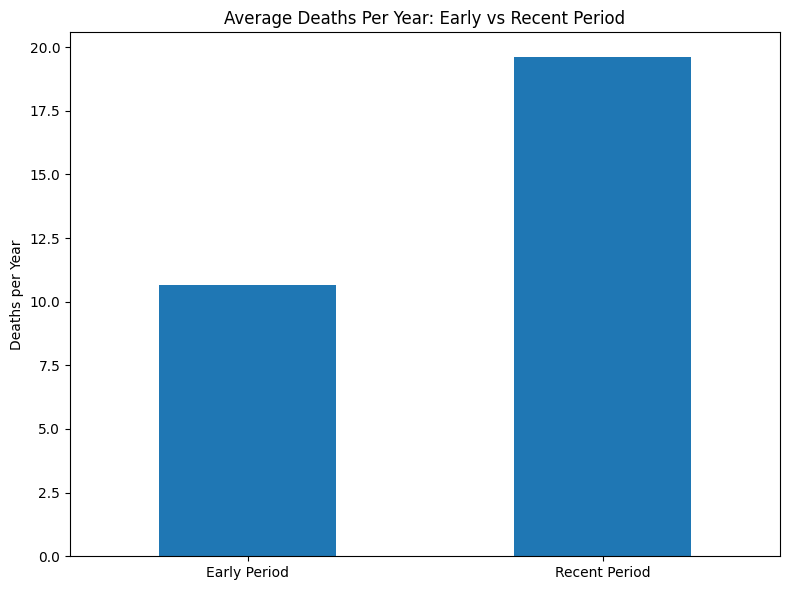

In [89]:
# Trend analysis
# Descriptive statistics (no regression)
# Split into time periods to see if risk is changing
median_year = allmountains['year'].median()

early_period = allmountains[allmountains['year'] <= median_year]
recent_period = allmountains[allmountains['year'] > median_year]

comparison = pd.DataFrame({
    'Early Period': [
        len(early_period),
        early_period['year'].nunique(),
        len(early_period) / early_period['year'].nunique()
    ],
    'Recent Period': [
        len(recent_period),
        recent_period['year'].nunique(),
        len(recent_period) / recent_period['year'].nunique()
    ]
}, index=['Total Deaths', 'Years Covered', 'Avg Deaths/Year'])

print(comparison)

# Visualize
comparison.loc['Avg Deaths/Year'].plot(kind='bar', figsize=(8,6))
plt.title('Average Deaths Per Year: Early vs Recent Period')
plt.ylabel('Deaths per Year')
plt.xticks(rotation=0)
plt.tight_layout()

# Save plot
plt.savefig('images/avgdeathsbyperiod.png', dpi=300, bbox_inches='tight')
plt.show()

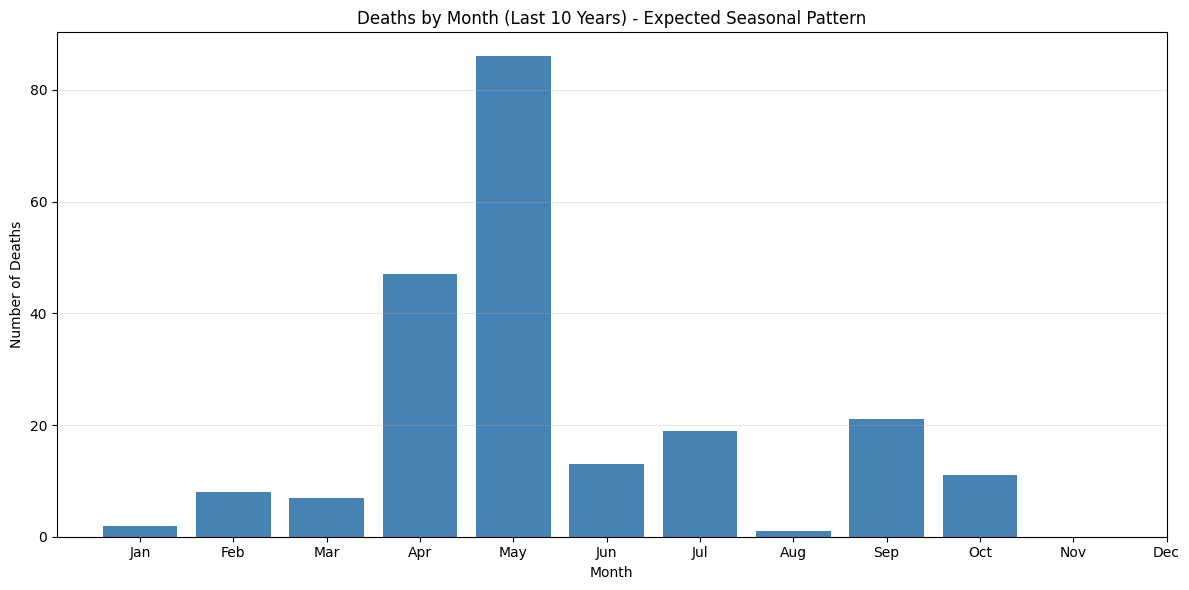

In [90]:
# Trend analysis
# Frequency counting (no regression)
# Which months are getting more dangerous over time?
months_recent = allmountains[allmountains['year'] >= (allmountains['year'].max() - 10)]
month_distribution = months_recent['month'].value_counts().sort_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12,6))
plt.bar(month_distribution.index, month_distribution.values, color='steelblue')
plt.title('Deaths by Month (Last 10 Years) - Expected Seasonal Pattern')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save plot
plt.savefig('images/seasonalpattern.png', dpi=300, bbox_inches='tight')
plt.show()

In [91]:
# LINEAR REGRESSION
model = stats.linregress(years, deaths)
print(f"For every year, deaths increase by {model.slope:.2f}")
print(f"Model explains {model.rvalue**2:.1%} of variance")
print(f"Predicted deaths in 2030: {model.slope * 2030 + model.intercept:.1f}")

For every year, deaths increase by 0.22
Model explains 41.9% of variance
Predicted deaths in 2030: 24.8


In [69]:
# Check if the relationship is still statistically significant
print(f"P-value: {model.pvalue}")
# If p < 0.05, the trend IS real, even if weak

P-value: 2.6586811935507373e-10


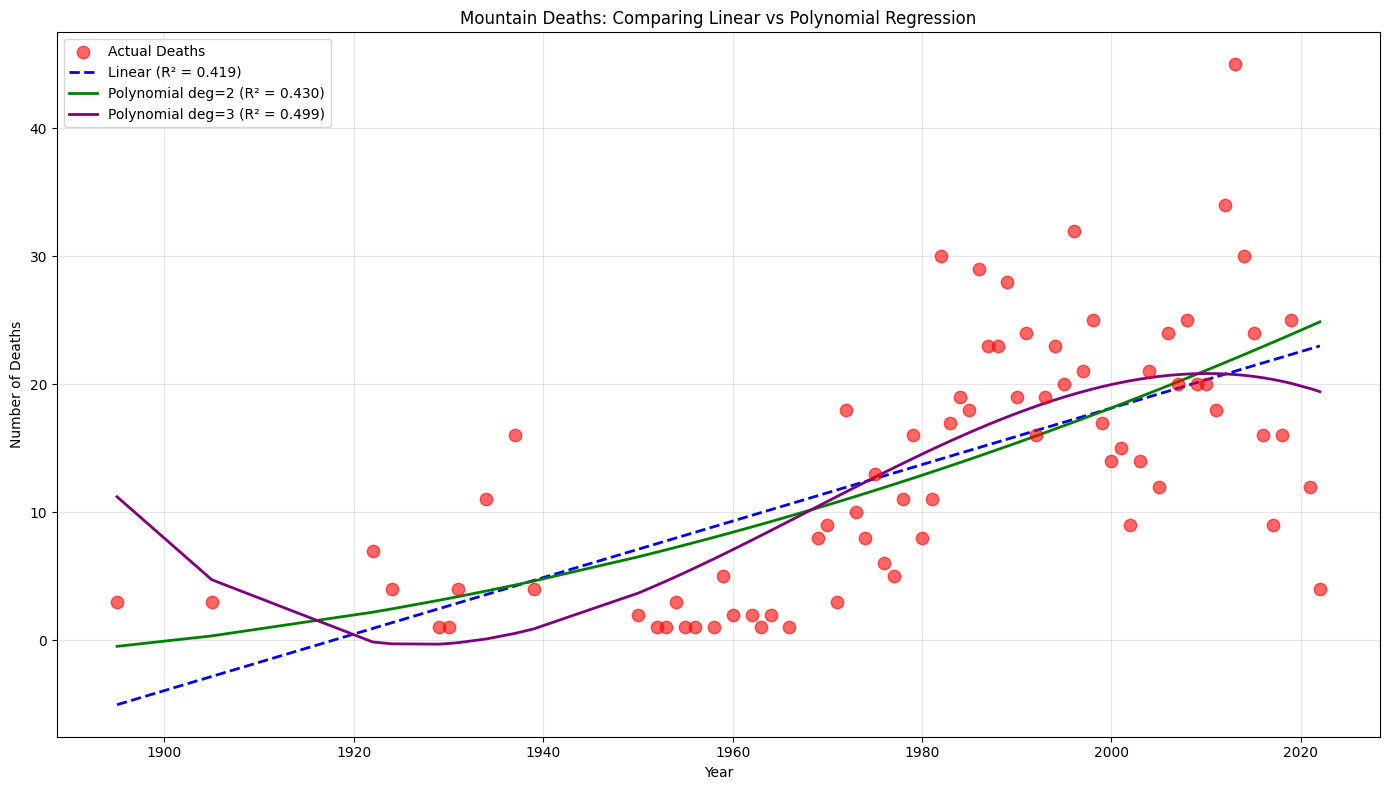

MODEL COMPARISON
Linear Regression:      R² = 0.4189 (41.89%)
Polynomial (degree 2):  R² = 0.4298 (42.98%)
Polynomial (degree 3):  R² = 0.4987 (49.87%)


In [92]:
# Polynomial regression
# Prepare the data
deaths_by_year = allmountains['year'].value_counts().sort_index()
years = deaths_by_year.index.values
deaths = deaths_by_year.values

# Linear regression (what we had before)
linear_model = stats.linregress(years, deaths)
linear_fit = linear_model.slope * years + linear_model.intercept
linear_r2 = linear_model.rvalue ** 2

# Polynomial regression (degree 2 - quadratic)
poly_coeffs_2 = np.polyfit(years, deaths, deg=2)
poly_model_2 = np.poly1d(poly_coeffs_2)
poly_fit_2 = poly_model_2(years)

# Calculate R² for polynomial
ss_res_2 = np.sum((deaths - poly_fit_2) ** 2)
ss_tot = np.sum((deaths - np.mean(deaths)) ** 2)
poly_r2_2 = 1 - (ss_res_2 / ss_tot)

# Polynomial regression (degree 3 - cubic)
poly_coeffs_3 = np.polyfit(years, deaths, deg=3)
poly_model_3 = np.poly1d(poly_coeffs_3)
poly_fit_3 = poly_model_3(years)

# Calculate R² for cubic
ss_res_3 = np.sum((deaths - poly_fit_3) ** 2)
poly_r2_3 = 1 - (ss_res_3 / ss_tot)

# Visualize comparison
plt.figure(figsize=(14, 8))
plt.scatter(years, deaths, color='red', s=80, alpha=0.6, label='Actual Deaths', zorder=3)
plt.plot(years, linear_fit, '--', color='blue', linewidth=2, 
         label=f'Linear (R² = {linear_r2:.3f})')
plt.plot(years, poly_fit_2, '-', color='green', linewidth=2, 
         label=f'Polynomial deg=2 (R² = {poly_r2_2:.3f})')
plt.plot(years, poly_fit_3, '-', color='purple', linewidth=2, 
         label=f'Polynomial deg=3 (R² = {poly_r2_3:.3f})')

plt.title('Mountain Deaths: Comparing Linear vs Polynomial Regression')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/lrmvprm.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison
print("MODEL COMPARISON")
print("=" * 50)
print(f"Linear Regression:      R² = {linear_r2:.4f} ({linear_r2*100:.2f}%)")
print(f"Polynomial (degree 2):  R² = {poly_r2_2:.4f} ({poly_r2_2*100:.2f}%)")
print(f"Polynomial (degree 3):  R² = {poly_r2_3:.4f} ({poly_r2_3*100:.2f}%)")
print("=" * 50)

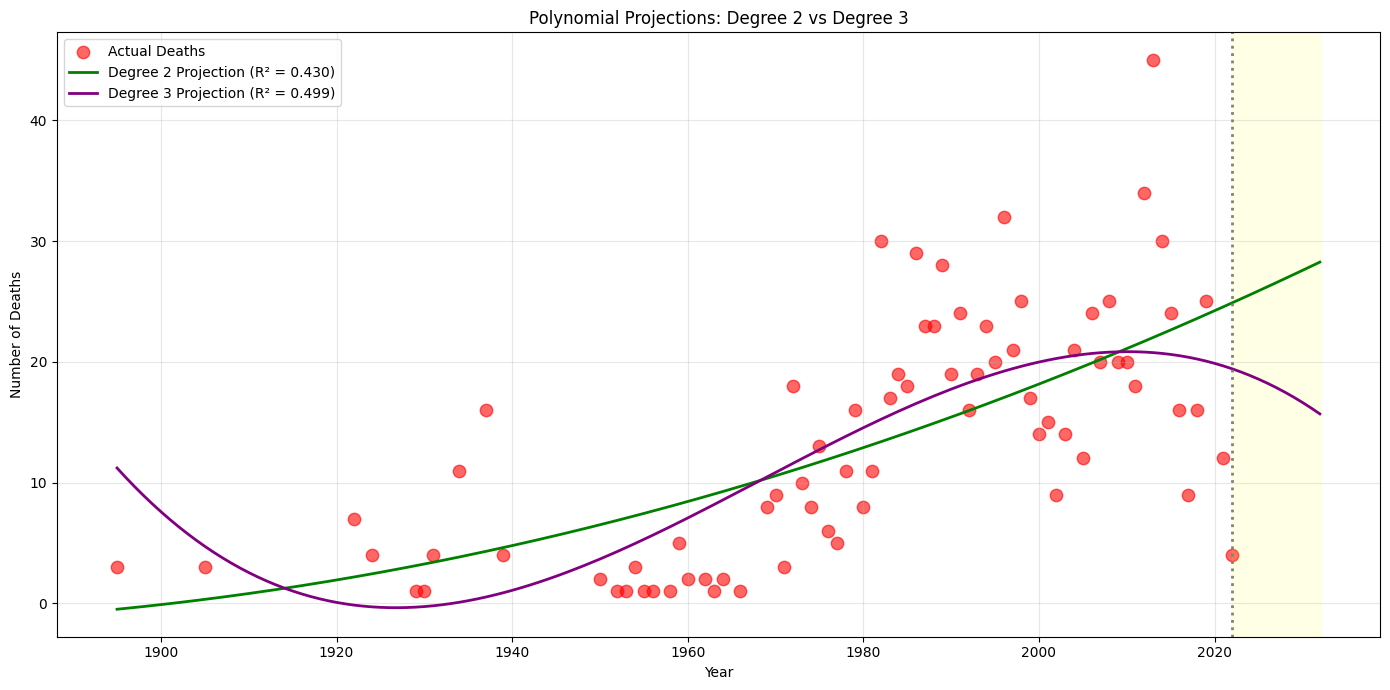

FUTURE PROJECTIONS COMPARISON:
Year       Deg 2           Deg 3          
2023             25.2            19.2
2027             26.5            17.9
2032             28.3            15.7


In [93]:
# Let's look at degree 3 projection carefully because it is the highest
future_years = np.arange(years.min(), years.max() + 11)
future_poly_3 = poly_model_3(future_years)

plt.figure(figsize=(14, 7))
plt.scatter(years, deaths, color='red', s=80, alpha=0.6, label='Actual Deaths')
plt.plot(future_years, poly_model_2(future_years), '-', color='green', 
         linewidth=2, label=f'Degree 2 Projection (R² = {poly_r2_2:.3f})')
plt.plot(future_years, future_poly_3, '-', color='purple', 
         linewidth=2, label=f'Degree 3 Projection (R² = {poly_r2_3:.3f})')
plt.axvline(x=years.max(), color='gray', linestyle=':', linewidth=2)
plt.axvspan(years.max(), future_years.max(), alpha=0.1, color='yellow')

plt.title('Polynomial Projections: Degree 2 vs Degree 3')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/deg2vdeg3.png', dpi=300, bbox_inches='tight')
plt.show()

# Check if degree 3 prediction is going crazy
print("FUTURE PROJECTIONS COMPARISON:")
print("=" * 60)
print(f"{'Year':<10} {'Deg 2':<15} {'Deg 3':<15}")
print("=" * 60)
for offset in [1, 5, 10]:
    year = years.max() + offset
    pred_2 = poly_model_2(year)
    pred_3 = poly_model_3(year)
    print(f"{year:<10} {pred_2:>10.1f}      {pred_3:>10.1f}")

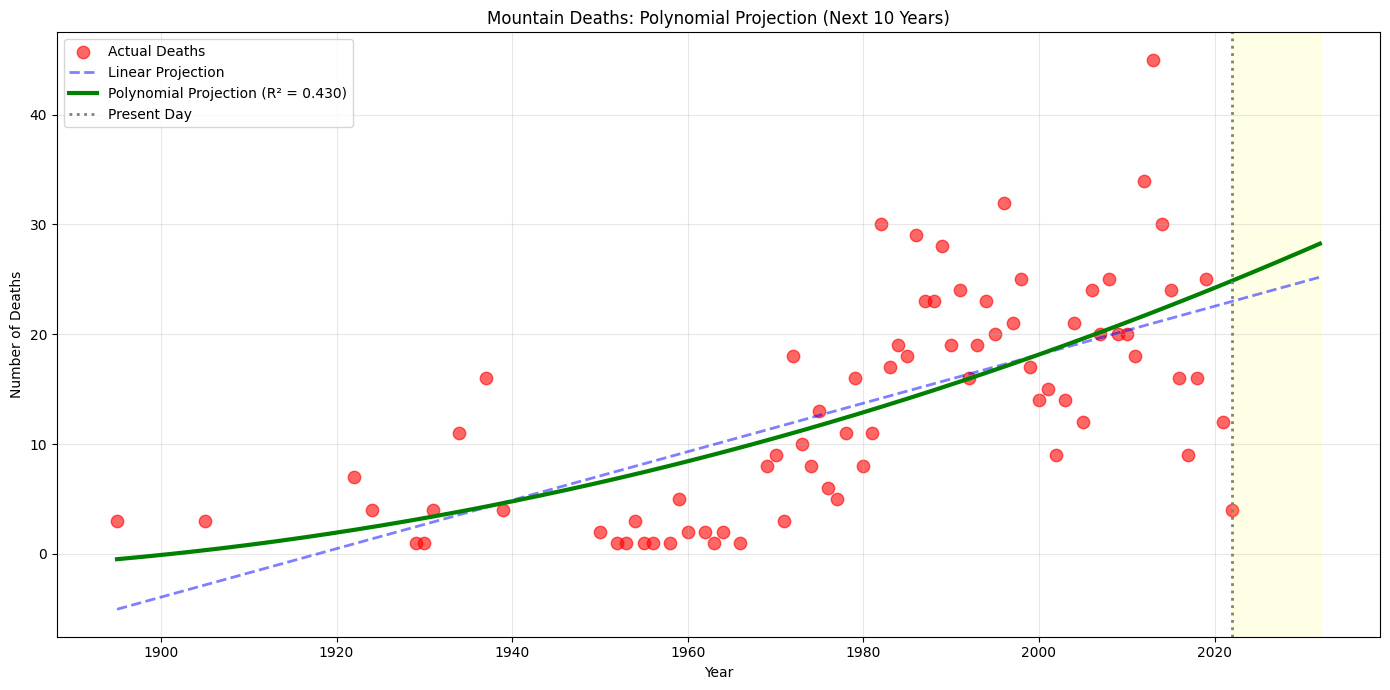


PROJECTIONS (Polynomial deg=2):
Year 2023 (+1 years): 25.2 deaths
Year 2027 (+5 years): 26.5 deaths
Year 2032 (+10 years): 28.3 deaths


In [94]:
# Project 10 years into the future
future_years = np.arange(years.min(), years.max() + 11)

# Use the polynomial model for projection (deg=2 usually best balance)
future_linear = linear_model.slope * future_years + linear_model.intercept
future_poly = poly_model_2(future_years)

plt.figure(figsize=(14, 7))
plt.scatter(years, deaths, color='red', s=80, alpha=0.6, label='Actual Deaths')
plt.plot(future_years, future_linear, '--', color='blue', linewidth=2, 
         alpha=0.5, label='Linear Projection')
plt.plot(future_years, future_poly, '-', color='green', linewidth=3, 
         label=f'Polynomial Projection (R² = {poly_r2_2:.3f})')
plt.axvline(x=years.max(), color='gray', linestyle=':', linewidth=2, 
            label='Present Day')

# Shade the projection area
plt.axvspan(years.max(), future_years.max(), alpha=0.1, color='yellow')

plt.title('Mountain Deaths: Polynomial Projection (Next 10 Years)')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/prmnext10years.png', dpi=300, bbox_inches='tight')
plt.show()

# Specific predictions
current_year = years.max()
print(f"\nPROJECTIONS (Polynomial deg=2):")
print("=" * 50)
for year_offset in [1, 5, 10]:
    future_year = current_year + year_offset
    prediction = poly_model_2(future_year)
    print(f"Year {future_year} (+{year_offset} years): {prediction:.1f} deaths")

In [95]:
# Store results for comparison
results = []

# Analyze each mountain
for mountain in allmountains['mountain'].unique():
    mountain_data = allmountains[allmountains['mountain'] == mountain]
    
    # Need at least 10 data points for meaningful regression
    if len(mountain_data) < 10:
        continue
    
    deaths_by_year = mountain_data['year'].value_counts().sort_index()
    
    # Need at least 5 different years
    if len(deaths_by_year) < 5:
        continue
    
    years = deaths_by_year.index.values
    deaths = deaths_by_year.values
    
    # Linear regression
    linear_model = stats.linregress(years, deaths)
    linear_r2 = linear_model.rvalue ** 2
    
    # Polynomial degree 2
    poly_coeffs = np.polyfit(years, deaths, deg=2)
    poly_model = np.poly1d(poly_coeffs)
    poly_fit = poly_model(years)
    ss_res = np.sum((deaths - poly_fit) ** 2)
    ss_tot = np.sum((deaths - np.mean(deaths)) ** 2)
    poly_r2 = 1 - (ss_res / ss_tot)
    
    results.append({
        'mountain': mountain,
        'total_deaths': len(mountain_data),
        'years_span': f"{years.min()}-{years.max()}",
        'avg_deaths_per_year': len(mountain_data) / len(deaths_by_year),
        'linear_r2': linear_r2,
        'poly_r2': poly_r2,
        'linear_slope': linear_model.slope,
        'p_value': linear_model.pvalue
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('total_deaths', ascending=False)

print("MOUNTAIN REGRESSION ANALYSIS")
print("=" * 100)
print(results_df.to_string(index=False))
print("\n")

# Summary insights
print("KEY INSIGHTS:")
print("=" * 100)
print(f"Mountains with best linear fit (R² > 0.5):")
print(results_df[results_df['linear_r2'] > 0.5][['mountain', 'linear_r2', 'linear_slope']])
print(f"\nMountains with increasing deaths (positive slope):")
print(results_df[results_df['linear_slope'] > 0][['mountain', 'linear_slope', 'total_deaths']])
print(f"\nMountains with decreasing deaths (negative slope):")
print(results_df[results_df['linear_slope'] < 0][['mountain', 'linear_slope', 'total_deaths']])

MOUNTAIN REGRESSION ANALYSIS
     mountain  total_deaths years_span  avg_deaths_per_year  linear_r2  poly_r2  linear_slope  p_value
      Everest           311  1922-2022             5.183333   0.150517 0.185152      0.066589 0.002192
           K2            92  1939-2021             3.066667   0.007243 0.007586      0.013762 0.654772
      Manaslu            86  1971-2021             2.687500   0.031487 0.069986     -0.040942 0.331255
 Nanga Parbat            85  1895-2019             3.035714   0.105843 0.111494     -0.041652 0.091155
 Dhaulagiri I            83  1954-2022             2.677419   0.002781 0.043403      0.005193 0.778140
  Annapurna I            73  1970-2019             2.517241   0.183116 0.188653     -0.054434 0.020574
Kangchenjunga            57  1905-2022             2.111111   0.006849 0.069799      0.003354 0.681515
       Chooyu            52  1958-2019             1.925926   0.005830 0.006193     -0.005847 0.705032
       Makalu            40  1954-2019      

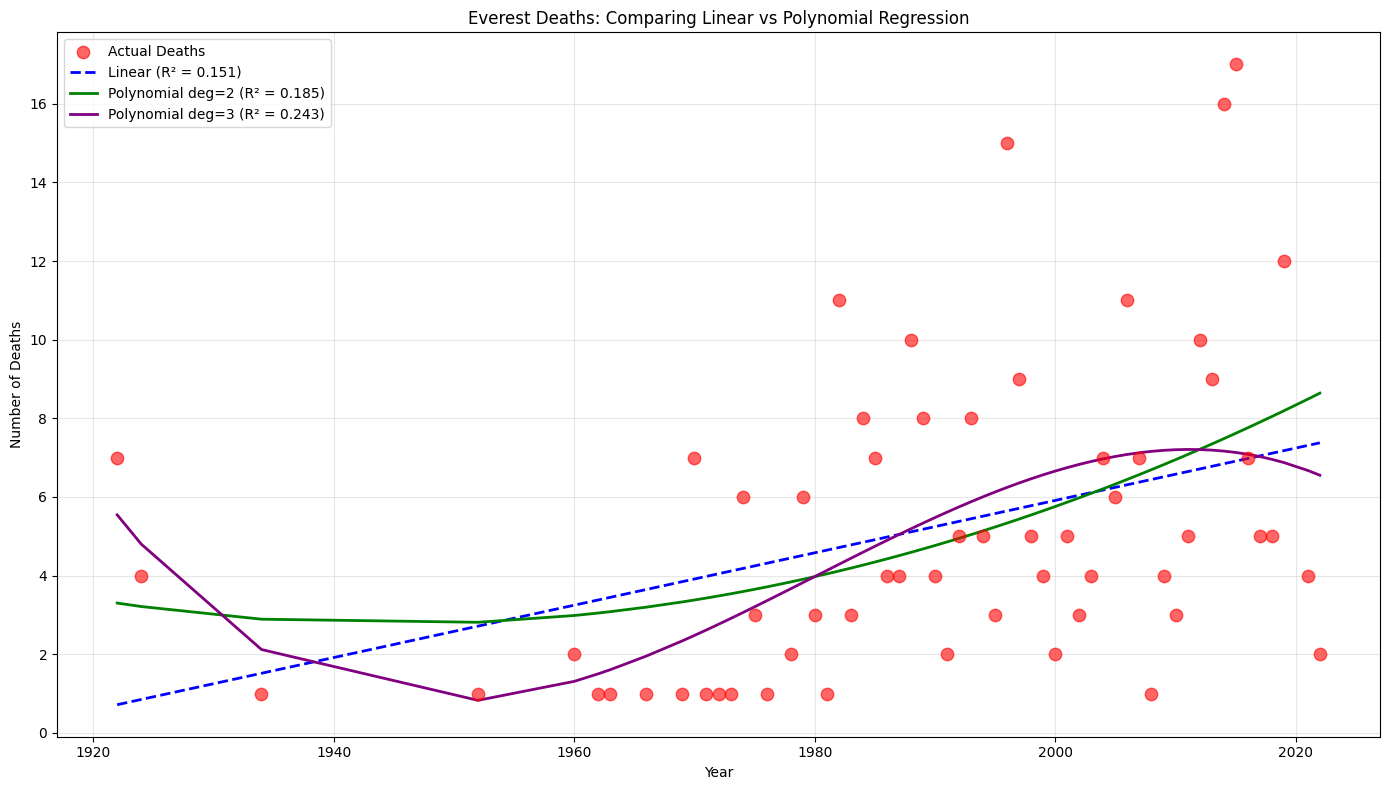

EVEREST MODEL COMPARISON
Linear Regression:      R² = 0.1505 (15.05%)
Polynomial (degree 2):  R² = 0.1852 (18.52%)
Polynomial (degree 3):  R² = 0.2428 (24.28%)


In [96]:
# Filter to Everest only
everest_data = allmountains[allmountains['mountain'] == 'Everest']

# Prepare the data
deaths_by_year = everest_data['year'].value_counts().sort_index()
years = deaths_by_year.index.values
deaths = deaths_by_year.values

# Linear regression
linear_model = stats.linregress(years, deaths)
linear_fit = linear_model.slope * years + linear_model.intercept
linear_r2 = linear_model.rvalue ** 2

# Polynomial regression (degree 2 - quadratic)
poly_coeffs_2 = np.polyfit(years, deaths, deg=2)
poly_model_2 = np.poly1d(poly_coeffs_2)
poly_fit_2 = poly_model_2(years)

# Calculate R² for polynomial
ss_res_2 = np.sum((deaths - poly_fit_2) ** 2)
ss_tot = np.sum((deaths - np.mean(deaths)) ** 2)
poly_r2_2 = 1 - (ss_res_2 / ss_tot)

# Polynomial regression (degree 3 - cubic)
poly_coeffs_3 = np.polyfit(years, deaths, deg=3)
poly_model_3 = np.poly1d(poly_coeffs_3)
poly_fit_3 = poly_model_3(years)

# Calculate R² for cubic
ss_res_3 = np.sum((deaths - poly_fit_3) ** 2)
poly_r2_3 = 1 - (ss_res_3 / ss_tot)

# Visualize comparison
plt.figure(figsize=(14, 8))
plt.scatter(years, deaths, color='red', s=80, alpha=0.6, label='Actual Deaths', zorder=3)
plt.plot(years, linear_fit, '--', color='blue', linewidth=2, 
         label=f'Linear (R² = {linear_r2:.3f})')
plt.plot(years, poly_fit_2, '-', color='green', linewidth=2, 
         label=f'Polynomial deg=2 (R² = {poly_r2_2:.3f})')
plt.plot(years, poly_fit_3, '-', color='purple', linewidth=2, 
         label=f'Polynomial deg=3 (R² = {poly_r2_3:.3f})')

plt.title('Everest Deaths: Comparing Linear vs Polynomial Regression')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_lrmvprm.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison
print("EVEREST MODEL COMPARISON")
print("=" * 50)
print(f"Linear Regression:      R² = {linear_r2:.4f} ({linear_r2*100:.2f}%)")
print(f"Polynomial (degree 2):  R² = {poly_r2_2:.4f} ({poly_r2_2*100:.2f}%)")
print(f"Polynomial (degree 3):  R² = {poly_r2_3:.4f} ({poly_r2_3*100:.2f}%)")
print("=" * 50)

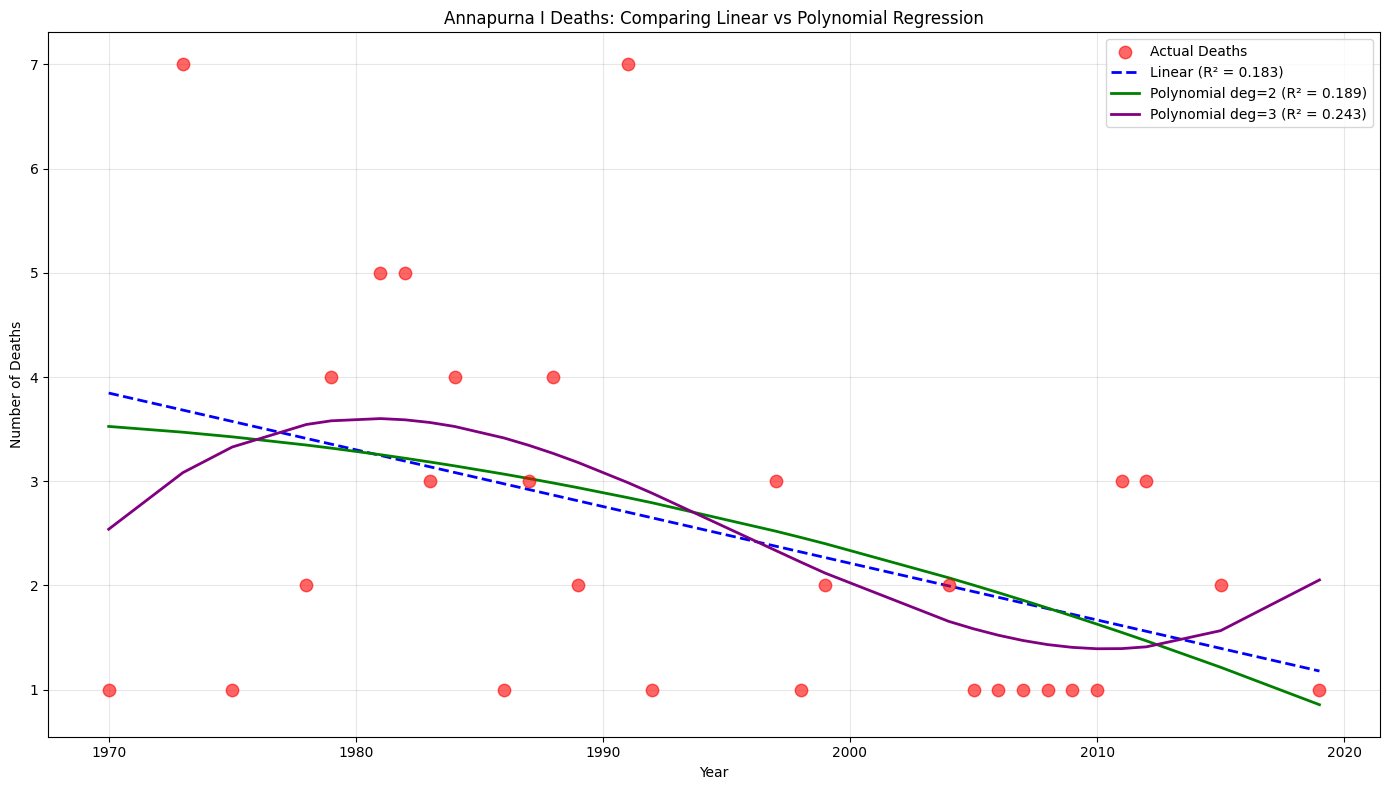

Annapurna I MODEL COMPARISON
Linear Regression:      R² = 0.1831 (18.31%)
Polynomial (degree 2):  R² = 0.1887 (18.87%)
Polynomial (degree 3):  R² = 0.2431 (24.31%)


In [99]:
# Filter to Everest only
annapurnaI_data = allmountains[allmountains['mountain'] == 'Annapurna I']

# Prepare the data
deaths_by_year = annapurnaI_data['year'].value_counts().sort_index()
years = deaths_by_year.index.values
deaths = deaths_by_year.values

# Linear regression
linear_model = stats.linregress(years, deaths)
linear_fit = linear_model.slope * years + linear_model.intercept
linear_r2 = linear_model.rvalue ** 2

# Polynomial regression (degree 2 - quadratic)
poly_coeffs_2 = np.polyfit(years, deaths, deg=2)
poly_model_2 = np.poly1d(poly_coeffs_2)
poly_fit_2 = poly_model_2(years)

# Calculate R² for polynomial
ss_res_2 = np.sum((deaths - poly_fit_2) ** 2)
ss_tot = np.sum((deaths - np.mean(deaths)) ** 2)
poly_r2_2 = 1 - (ss_res_2 / ss_tot)

# Polynomial regression (degree 3 - cubic)
poly_coeffs_3 = np.polyfit(years, deaths, deg=3)
poly_model_3 = np.poly1d(poly_coeffs_3)
poly_fit_3 = poly_model_3(years)

# Calculate R² for cubic
ss_res_3 = np.sum((deaths - poly_fit_3) ** 2)
poly_r2_3 = 1 - (ss_res_3 / ss_tot)

# Visualize comparison
plt.figure(figsize=(14, 8))
plt.scatter(years, deaths, color='red', s=80, alpha=0.6, label='Actual Deaths', zorder=3)
plt.plot(years, linear_fit, '--', color='blue', linewidth=2, 
         label=f'Linear (R² = {linear_r2:.3f})')
plt.plot(years, poly_fit_2, '-', color='green', linewidth=2, 
         label=f'Polynomial deg=2 (R² = {poly_r2_2:.3f})')
plt.plot(years, poly_fit_3, '-', color='purple', linewidth=2, 
         label=f'Polynomial deg=3 (R² = {poly_r2_3:.3f})')

plt.title('Annapurna I Deaths: Comparing Linear vs Polynomial Regression')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/annapurnaI_lrmvprm.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison
print("Annapurna I MODEL COMPARISON")
print("=" * 50)
print(f"Linear Regression:      R² = {linear_r2:.4f} ({linear_r2*100:.2f}%)")
print(f"Polynomial (degree 2):  R² = {poly_r2_2:.4f} ({poly_r2_2*100:.2f}%)")
print(f"Polynomial (degree 3):  R² = {poly_r2_3:.4f} ({poly_r2_3*100:.2f}%)")
print("=" * 50)

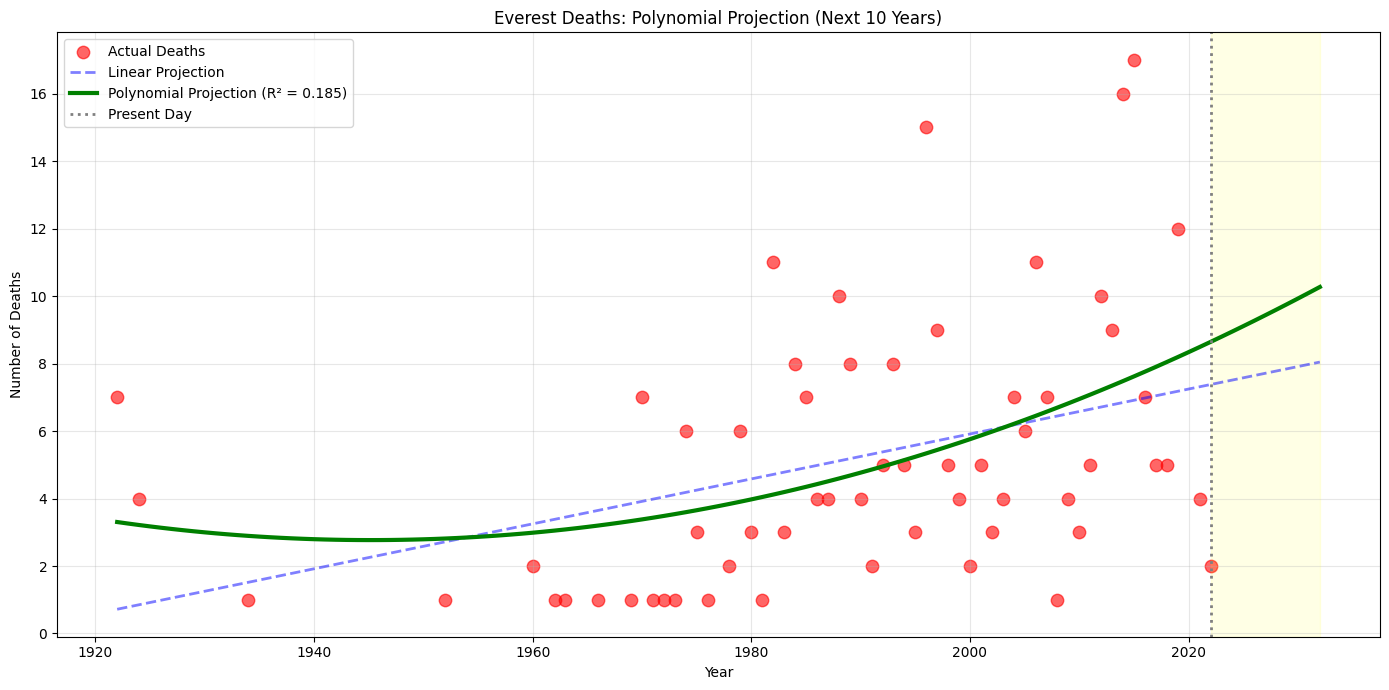


EVEREST PROJECTIONS (Polynomial deg=2):
Year 2023 (+1 years): 8.8 deaths
Year 2027 (+5 years): 9.4 deaths
Year 2032 (+10 years): 10.3 deaths


In [101]:
# Filter to specific mountain
mountain_name = 'Everest'  # Change this to any mountain
mountain_data = allmountains[allmountains['mountain'] == mountain_name]

# Prepare the data
deaths_by_year = mountain_data['year'].value_counts().sort_index()
years = deaths_by_year.index.values
deaths = deaths_by_year.values

# Linear regression
linear_model = stats.linregress(years, deaths)

# Polynomial degree 2
poly_coeffs_2 = np.polyfit(years, deaths, deg=2)
poly_model_2 = np.poly1d(poly_coeffs_2)

# Calculate R² for polynomial
poly_fit_2 = poly_model_2(years)
ss_res_2 = np.sum((deaths - poly_fit_2) ** 2)
ss_tot = np.sum((deaths - np.mean(deaths)) ** 2)
poly_r2_2 = 1 - (ss_res_2 / ss_tot)

# Project 10 years into the future
future_years = np.arange(years.min(), years.max() + 11)

# Use the polynomial model for projection
future_linear = linear_model.slope * future_years + linear_model.intercept
future_poly = poly_model_2(future_years)

plt.figure(figsize=(14, 7))
plt.scatter(years, deaths, color='red', s=80, alpha=0.6, label='Actual Deaths')
plt.plot(future_years, future_linear, '--', color='blue', linewidth=2, 
         alpha=0.5, label='Linear Projection')
plt.plot(future_years, future_poly, '-', color='green', linewidth=3, 
         label=f'Polynomial Projection (R² = {poly_r2_2:.3f})')
plt.axvline(x=years.max(), color='gray', linestyle=':', linewidth=2, 
            label='Present Day')

# Shade the projection area
plt.axvspan(years.max(), future_years.max(), alpha=0.1, color='yellow')

plt.title(f'{mountain_name} Deaths: Polynomial Projection (Next 10 Years)')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig(f'images/{mountain_name.replace(" ", "_").lower()}_projection.png', dpi=300, bbox_inches='tight')
plt.show()

# Specific predictions
current_year = years.max()
print(f"\n{mountain_name.upper()} PROJECTIONS (Polynomial deg=2):")
print("=" * 50)
for year_offset in [1, 5, 10]:
    future_year = current_year + year_offset
    prediction = poly_model_2(future_year)
    print(f"Year {future_year} (+{year_offset} years): {prediction:.1f} deaths")